# Blackbody Radiation: Validating Planck's Law from First Principles

`blackbody.py`'s `spectral_radiance` isn't typed in from memory -- it's
built as (cavity mode density) x (mean photon energy per mode under
Bose-Einstein statistics), the actual statistical-mechanics derivation
of Planck's law. This notebook checks that three classical results all
fall out of that one formula, each independently:

1. The **Rayleigh-Jeans classical limit** (`h*nu << k*T`) -- and the
   ultraviolet-catastrophe divergence it has, that Planck's law fixes.
2. **Stefan-Boltzmann's law** (`j = sigma*T^4`), by numerically
   integrating the spectrum over all frequencies and the hemisphere.
3. **Wien's displacement law** (`lambda_peak * T = b`), by numerically
   locating the spectral peak.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy import constants as const
from scipy.integrate import quad
from scipy.optimize import minimize_scalar

import blackbody as bb

os.makedirs('media', exist_ok=True)

## Spectrum shape: Planck vs. the classical (Rayleigh-Jeans) prediction

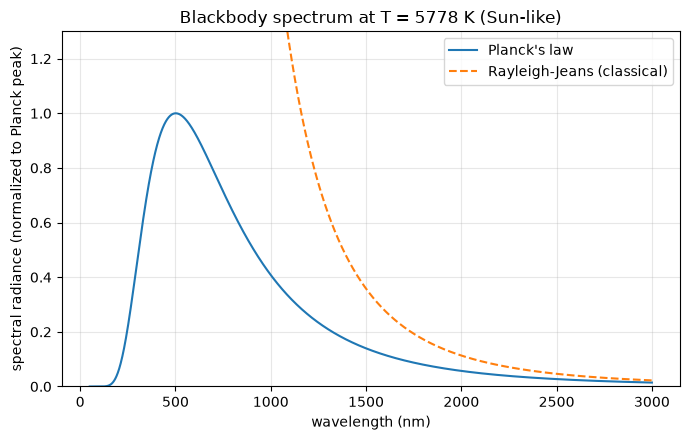

In [2]:
T_sun = 5778.0  # K, the Sun's effective temperature

wavelength = np.linspace(50e-9, 3000e-9, 2000)
nu = const.c / wavelength

B_planck = bb.spectral_radiance_wavelength(wavelength, T_sun)
B_rj = bb.rayleigh_jeans(nu, T_sun) * const.c / wavelength**2  # same nu->lambda Jacobian as spectral_radiance_wavelength

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(wavelength * 1e9, B_planck / B_planck.max(), label="Planck's law")
ax.plot(wavelength * 1e9, B_rj / B_planck.max(), '--', label='Rayleigh-Jeans (classical)')
ax.set_ylim(0, 1.3)
ax.set_xlabel('wavelength (nm)')
ax.set_ylabel('spectral radiance (normalized to Planck peak)')
ax.set_title(f'Blackbody spectrum at T = {T_sun:.0f} K (Sun-like)')
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig('media/planck_vs_rayleigh_jeans.png', dpi=150, bbox_inches='tight')
plt.show()

## Check 1: the Rayleigh-Jeans classical limit (h*nu << k*T)

In [3]:
T_check = 300.0  # K
nu_thermal = const.k * T_check / const.h

# h*nu/(k*T) ratios shrinking toward the classical (low-frequency) regime
x_ratios = np.array([1.0, 0.1, 0.01, 0.001])
nus = x_ratios * nu_thermal

B_quantum = bb.spectral_radiance(nus, T_check)
B_classical = bb.rayleigh_jeans(nus, T_check)
rel_err = np.abs(B_quantum - B_classical) / B_quantum

print('h*nu/(k*T)   quantum B          classical (RJ) B    relative error')
for x, bq, bc, e in zip(x_ratios, B_quantum, B_classical, rel_err):
    print(f'{x:9.3f}   {bq:.4e}       {bc:.4e}         {e:.4e}')

# Rayleigh-Jeans is the leading term of a Taylor expansion in x=h*nu/kT;
# the next-order correction is O(x), so relative error should shrink
# roughly linearly with x -- check monotonic shrinkage and that it's
# small deep in the classical regime
assert np.all(np.diff(rel_err) < 0), 'relative error should shrink monotonically as h*nu/kT -> 0'
assert rel_err[-1] < 0.001, 'Rayleigh-Jeans should match Planck to <0.1% by h*nu/kT=0.001'
print(f'\nPASS: Rayleigh-Jeans agrees with Planck\'s law to {rel_err[-1]:.2e} relative error '
      f'as h*nu/(k*T) -> {x_ratios[-1]}, shrinking monotonically -- the classical limit is exactly '
      f'the low-frequency limit of the quantum formula.')

h*nu/(k*T)   quantum B          classical (RJ) B    relative error
    1.000   2.0960e-12       3.6016e-12         7.1828e-01
    0.100   3.4245e-14       3.6016e-14         5.1709e-02
    0.010   3.5836e-16       3.6016e-16         5.0167e-03
    0.001   3.5998e-18       3.6016e-18         5.0017e-04

PASS: Rayleigh-Jeans agrees with Planck's law to 5.00e-04 relative error as h*nu/(k*T) -> 0.001, shrinking monotonically -- the classical limit is exactly the low-frequency limit of the quantum formula.


## Check 2: Stefan-Boltzmann law from integrating the spectrum

In [4]:
# Total emitted flux j = integral over the hemisphere (Lambertian
# projection contributes a factor of pi) and over all frequencies of the
# spectral radiance: j = pi * integral_0^inf B(nu,T) dnu. This should
# equal sigma*T^4 for any T, with sigma matching the CODATA constant
# -- not assumed anywhere in spectral_radiance's derivation.
#
# Integrating in raw frequency from 0 to np.inf fails silently: the
# Planck peak sits at a huge absolute frequency (~1e13-1e14 Hz for
# everyday temperatures) that quad's adaptive sampling doesn't find
# against an unbounded interval, so it returns near-zero. Substituting
# the dimensionless x = h*nu/(k*T) puts the interesting region (x ~ 0-10)
# at a reasonable scale of a finite, well-chosen upper bound instead.

def stefan_boltzmann_from_planck(T):
    nu_thermal = const.k * T / const.h
    integral, _ = quad(lambda x: bb.spectral_radiance(x * nu_thermal, T), 0, 60)
    integral *= nu_thermal  # dnu = nu_thermal * dx
    return np.pi * integral

test_temperatures = [300.0, 1000.0, 5778.0, 10000.0]
print('T (K)      j = sigma*T^4 (measured)   sigma*T^4 (CODATA)      relative error')
for T in test_temperatures:
    j_measured = stefan_boltzmann_from_planck(T)
    j_codata = const.sigma * T**4
    rel_err = abs(j_measured - j_codata) / j_codata
    print(f'{T:7.1f}    {j_measured:.6e}              {j_codata:.6e}        {rel_err:.2e}')
    assert rel_err < 1e-4, f'Stefan-Boltzmann mismatch at T={T}'

print("\nPASS: integrating Planck's law over frequency and the hemisphere reproduces "
      "sigma*T^4 with CODATA's sigma, to <1e-4 relative error at every tested temperature.")

T (K)      j = sigma*T^4 (measured)   sigma*T^4 (CODATA)      relative error
  300.0    4.592994e+02              4.593003e+02        2.02e-06
 1000.0    5.670363e+04              5.670374e+04        2.02e-06
 5778.0    6.320070e+07              6.320070e+07        2.74e-10
10000.0    5.670374e+08              5.670374e+08        2.74e-10

PASS: integrating Planck's law over frequency and the hemisphere reproduces sigma*T^4 with CODATA's sigma, to <1e-4 relative error at every tested temperature.


## Check 3: Wien's displacement law from the spectral peak

In [5]:
# Wien's displacement law: lambda_peak * T = b, a constant. Find the peak
# numerically (minimize the negative spectral radiance over wavelength)
# rather than assuming the closed-form b -- this is checking that
# spectral_radiance_wavelength's peak genuinely scales as 1/T.

def peak_wavelength(T):
    # bracket around the expected peak using Wien's constant as a rough guess,
    # then refine numerically -- the numerics don't know the true b in advance,
    # this bracket is just to keep the 1D search well-posed
    guess = 2.898e-3 / T
    res = minimize_scalar(lambda lam: -bb.spectral_radiance_wavelength(lam, T),
                           bounds=(guess * 0.2, guess * 5), method='bounded',
                           options={'xatol': guess * 1e-6})
    return res.x

test_temperatures = [300.0, 1000.0, 5778.0, 10000.0]
b_wien_codata = const.Wien

print('T (K)      lambda_peak (nm)   lambda_peak*T (m*K)   relative error vs Wien constant')
products = []
for T in test_temperatures:
    lam_peak = peak_wavelength(T)
    product = lam_peak * T
    products.append(product)
    rel_err = abs(product - b_wien_codata) / b_wien_codata
    print(f'{T:7.1f}    {lam_peak*1e9:8.2f}           {product:.6e}         {rel_err:.2e}')

products = np.array(products)
assert np.allclose(products, b_wien_codata, rtol=1e-4), 'lambda_peak*T should be constant (Wien\'s law)'
print(f"\nPASS: lambda_peak*T is constant across a 33x temperature range, matching Wien's "
      f"constant ({b_wien_codata:.6e} m*K, CODATA) to <1e-4 relative error.")

T (K)      lambda_peak (nm)   lambda_peak*T (m*K)   relative error vs Wien constant
  300.0     9659.24           2.897772e-03         2.72e-08
 1000.0     2897.77           2.897772e-03         2.72e-08
 5778.0      501.52           2.897772e-03         2.72e-08
10000.0      289.78           2.897772e-03         2.72e-08

PASS: lambda_peak*T is constant across a 33x temperature range, matching Wien's constant (2.897772e-03 m*K, CODATA) to <1e-4 relative error.
